# Loan Default Prediction

In [1]:
# %pip install tensorflow

In [2]:
%load_ext autoreload
%autoreload 2

from scripts.utilities import *
from scripts.features import *

c:\Users\bdion\Downloads\DSC180B\DSC180B\.conda\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load and Process Data

In [3]:
 # Load raw data
consumer_df, account_df, transaction_df = get_data()

# Filter consumers with no transaction or balance information
#consumer_df, account_df, transaction_df = filter_unknown(consumer_df, account_df, transaction_df)

Data successfully loaded and processed.


In [4]:
consumer_df

,prism_consumer_id,evaluation_date,credit_score,DQ_TARGET
0,0,2021-09-01,726.0,0.0
1,1,2021-07-01,626.0,0.0
2,2,2021-05-01,680.0,0.0
3,3,2021-03-01,734.0,0.0
4,4,2021-10-01,676.0,0.0
...,...,...,...,...
14995,14995,2022-03-08,655.0,NaN
14996,14996,2022-01-15,625.0,NaN
14997,14997,2022-01-31,688.0,NaN
14998,14998,2022-03-08,722.0,NaN


In [5]:
transaction_df

,prism_consumer_id,prism_transaction_id,amount,credit_or_debit,posted_date,category
0,3023,0,0.05,CREDIT,2021-04-16,MISCELLANEOUS
1,3023,1,481.56,CREDIT,2021-04-30,LOAN
2,3023,2,0.05,CREDIT,2021-05-16,MISCELLANEOUS
3,3023,3,0.07,CREDIT,2021-06-16,MISCELLANEOUS
4,3023,4,0.06,CREDIT,2021-07-16,MISCELLANEOUS
...,...,...,...,...,...,...
6407316,10533,6405304,4.96,DEBIT,2022-03-11,BILLS_UTILITIES
6407317,10533,6405305,63.48,DEBIT,2022-03-30,LOAN
6407318,10533,6405306,53.99,DEBIT,2022-03-30,LOAN
6407319,10533,6405307,175.98,DEBIT,2022-03-31,LOAN


### Scoring Exclusion
Filtering out consumers with thin files





In [6]:
enriched_df = identify_thin_files(
    transaction_df, 
    account_df, 
    consumer_df,
    min_transactions=3,
    min_transaction_months=1,
    min_balance_records=1
)

# Analyze thin file characteristics
analyze_thin_files(enriched_df)

# Filter out thin files before feature creation
thick_file_consumers = enriched_df[~enriched_df['is_thin_file']]['prism_consumer_id']

# Filter your dataframes
filtered_consumer_df = consumer_df[consumer_df['prism_consumer_id'].isin(thick_file_consumers)]
filtered_account_df = account_df[account_df['prism_consumer_id'].isin(thick_file_consumers)]
filtered_transaction_df = transaction_df[transaction_df['prism_consumer_id'].isin(thick_file_consumers)]

Data Sufficiency Analysis
--------------------------------------------------

Overall Thin File Rate:
is_thin_file
False    0.826
True     0.174
Name: proportion, dtype: float64

Insufficiency Reasons:

insufficient_transactions:
insufficient_transactions
False    0.948
True     0.052
Name: proportion, dtype: float64

insufficient_transaction_history:
insufficient_transaction_history
False    0.966
True     0.034
Name: proportion, dtype: float64

insufficient_balance_records:
insufficient_balance_records
False    0.867
True     0.133
Name: proportion, dtype: float64

Default Rates Comparison:
Thin Files Default Rate: 0.072
Thick Files Default Rate: 0.086

Data Metrics Distribution:

total_transactions:
count    15000.00
mean       427.15
std        397.57
min          0.00
25%        154.00
50%        337.00
75%        589.00
max       8478.00
Name: total_transactions, dtype: float64

months_with_transactions:
count    15000.00
mean         5.97
std          2.62
min          0.00
25% 

In [7]:
analyze_exclusion_impact(consumer_df, filtered_consumer_df)

Exclusion Impact Analysis
--------------------------------------------------

Sample Size Impact:
Original samples: 15000
Filtered samples: 12392
Reduction: 17.4%

Default Rate Impact:
Original default rate: 0.084
Filtered default rate: 0.086

Credit Score Distribution:
Original:
count    15000.00
mean       661.19
std         76.53
min        353.00
25%        618.00
50%        661.00
75%        712.00
max        850.00
Name: credit_score, dtype: float64

Filtered:
count    12392.00
mean       661.38
std         79.33
min        353.00
25%        614.00
50%        661.00
75%        716.00
max        850.00
Name: credit_score, dtype: float64


In [8]:
# replace the original dataframes with the filtered dataframes
consumer_df = filtered_consumer_df
account_df = filtered_account_df
transaction_df = filtered_transaction_df

# display filtered dataframes
consumer_df

,prism_consumer_id,evaluation_date,credit_score,DQ_TARGET
0,0,2021-09-01,726.0,0.0
1,1,2021-07-01,626.0,0.0
2,2,2021-05-01,680.0,0.0
3,3,2021-03-01,734.0,0.0
4,4,2021-10-01,676.0,0.0
...,...,...,...,...
14991,14991,2022-01-26,667.0,NaN
14992,14992,2022-03-14,709.0,NaN
14994,14994,2022-01-15,616.0,NaN
14996,14996,2022-01-15,625.0,NaN


### Feature Creation

In [ ]:
# Define feature functions
selected_features = [
    average_transaction_amount,
    net_monthly_cash_flow,
    average_account_balance,
    time_based_average_transaction_amounts,
    descriptive_stats_by_category,
    outflow_stats,
    outflow_over_time_fix,
    balance_over_time,
    credit_score
]

# Calculate features
feature_dataframes = execute_selected_features(selected_features, consumer_df, account_df, transaction_df)
final_features = merge_features(feature_dataframes)

# Merge with consumer data
ml_features = consumer_df.merge(final_features, how="left", on="prism_consumer_id")
ml_features = ml_features.apply(lambda col: col.fillna(0) if col.name != "DQ_TARGET" else col)


Feature Execution Plan:
- Total feature creation functions: 8
- Unchanged feature creation functions: 8 (using cached results)

No feature creation functions need to be executed.
- Using cached result for average_transaction_amount
- Using cached result for net_monthly_cash_flow
- Using cached result for average_account_balance
- Using cached result for time_based_average_transaction_amounts
- Using cached result for descriptive_stats_by_category
- Using cached result for outflow_stats
- Using cached result for outflow_over_time_fix
- Using cached result for balance_over_time

Total Created Features:  266


## 2 Split Data

In [10]:
# Split with validation set for hyperparameter tuning
train_df, _, test_df = split_data(ml_features, test_size=0.25)

# Define feature columns
exclude_columns = ['prism_consumer_id', 'evaluation_date', 'credit_score', 'DQ_TARGET']
all_feature_columns = [col for col in train_df.columns if col not in exclude_columns]

Training set size: 7447
No validation set created.
Test set size: 2483


## 3. All Model Performances

In [11]:
summary_table = evaluate_feature_model_combinations(train_df, test_df, all_feature_columns)

Evaluating: Feature Selection = all_features, Model = xgboost
Evaluating: Feature Selection = all_features, Model = gradient_boosting
Evaluating: Feature Selection = all_features, Model = random_forest
Evaluating: Feature Selection = all_features, Model = logistic
Evaluating: Feature Selection = mutual_info, Model = xgboost
Evaluating: Feature Selection = mutual_info, Model = gradient_boosting
Evaluating: Feature Selection = mutual_info, Model = random_forest
Evaluating: Feature Selection = mutual_info, Model = logistic
Evaluating: Feature Selection = random_forest, Model = xgboost
Evaluating: Feature Selection = random_forest, Model = gradient_boosting
Evaluating: Feature Selection = random_forest, Model = random_forest
Evaluating: Feature Selection = random_forest, Model = logistic
Evaluating: Feature Selection = xgboost, Model = xgboost
Evaluating: Feature Selection = xgboost, Model = gradient_boosting
Evaluating: Feature Selection = xgboost, Model = random_forest
Evaluating: Featur

In [12]:
summary_table

,Feature Selection,Model,Test Accuracy,Test Balanced Accuracy,Test ROC AUC
0,all_features,xgboost,0.79,0.73,0.81
1,all_features,gradient_boosting,0.92,0.53,0.81
2,all_features,random_forest,0.92,0.52,0.80
3,all_features,logistic,0.70,0.71,0.76
4,mutual_info,xgboost,0.76,0.71,0.81
5,mutual_info,gradient_boosting,0.92,0.52,0.81
6,mutual_info,random_forest,0.92,0.52,0.79
7,mutual_info,logistic,0.67,0.70,0.75
8,random_forest,xgboost,0.78,0.73,0.82
9,random_forest,gradient_boosting,0.92,0.54,0.81


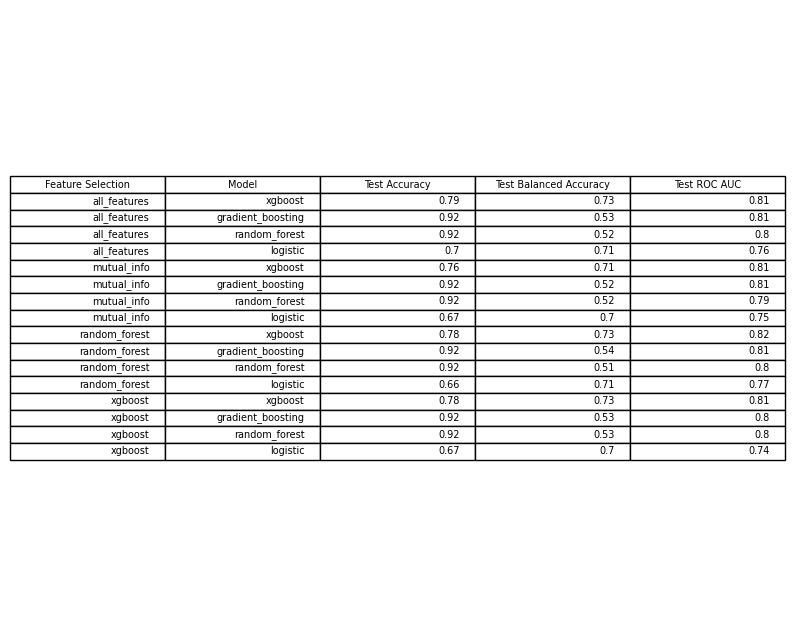

In [13]:
# Set up the matplotlib figure and axis
fig, ax = plt.subplots(figsize=(len(summary_table.columns) * 2, len(summary_table) * 0.5))
ax.axis('tight')
ax.axis('off')

# Create the table plot from the DataFrame
table = ax.table(cellText=summary_table.values, colLabels=summary_table.columns, loc='center')
 
# Save the figure as an image file
plt.show()

## 4. Individual Model Training

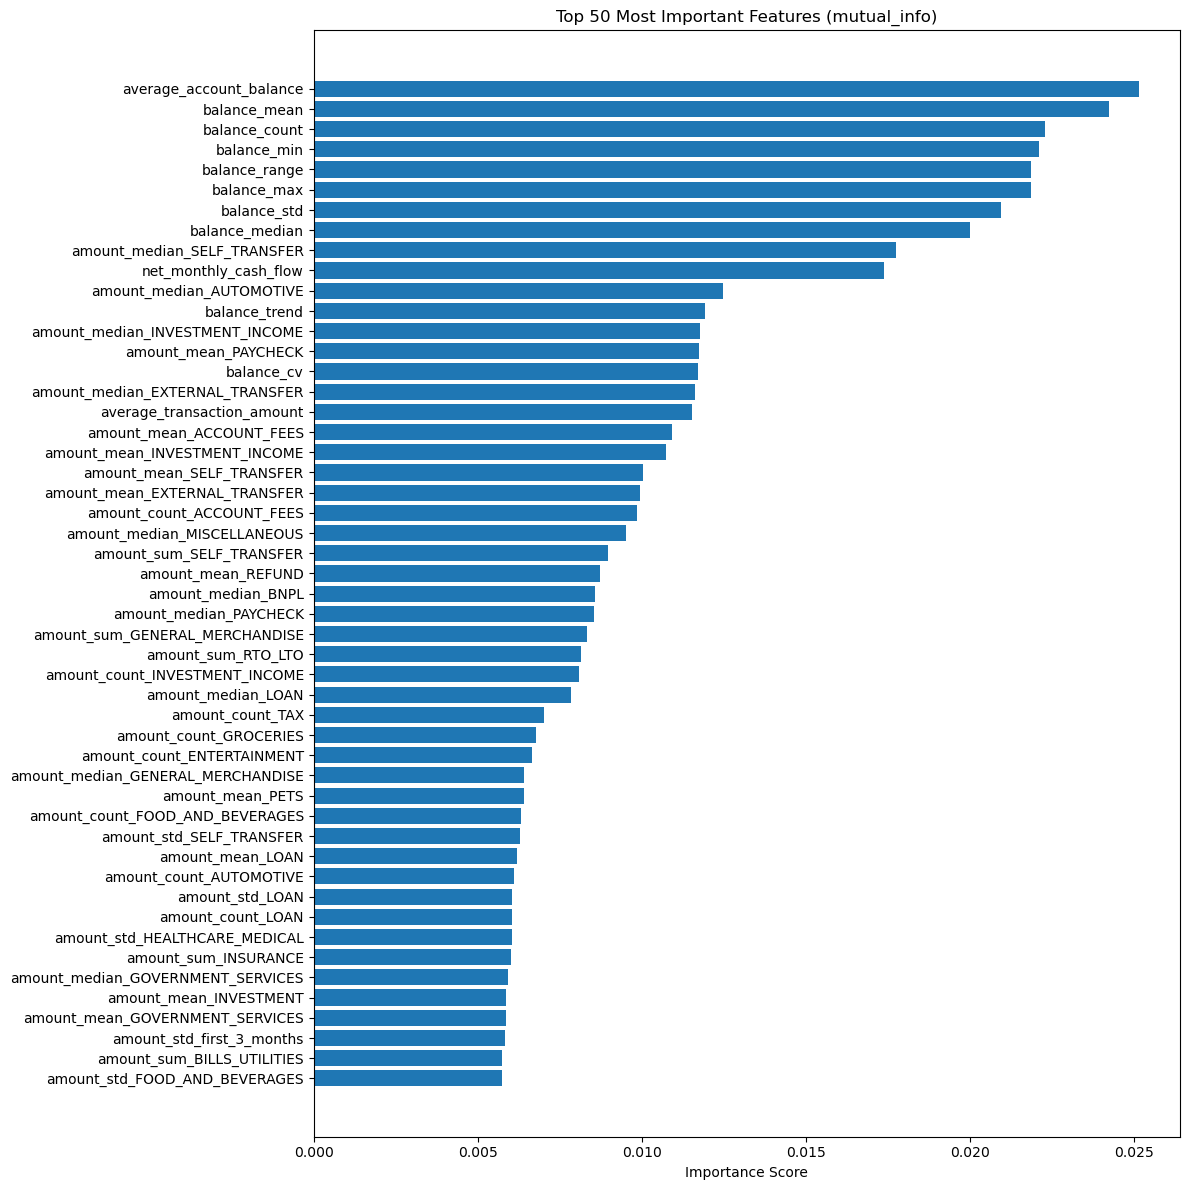

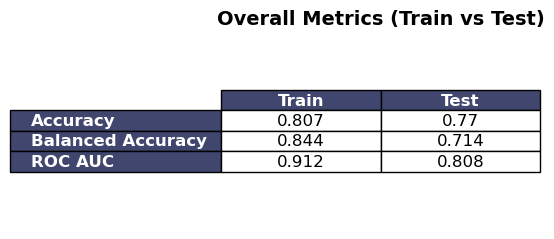


=== Classification Report (Train vs Test) ===
                 Train                                       Test                                 
             precision    recall  f1-score      support precision    recall  f1-score      support
0.0           0.986911  0.798970  0.883051  6795.000000  0.961102  0.780606  0.861501  2279.000000
1.0           0.298047  0.889571  0.446497   652.000000  0.208861  0.647059  0.315789   204.000000
accuracy      0.806902  0.806902  0.806902     0.806902  0.769634  0.769634  0.769634     0.769634
macro avg     0.642479  0.844270  0.664774  7447.000000  0.584981  0.713832  0.588645  2483.000000
weighted avg  0.926600  0.806902  0.844830  7447.000000  0.899299  0.769634  0.816666  2483.000000


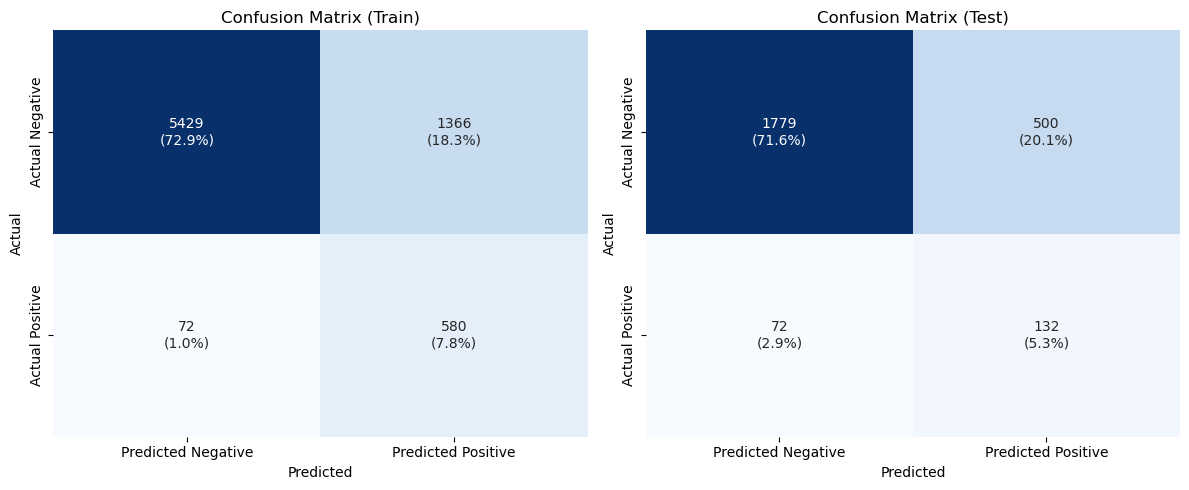

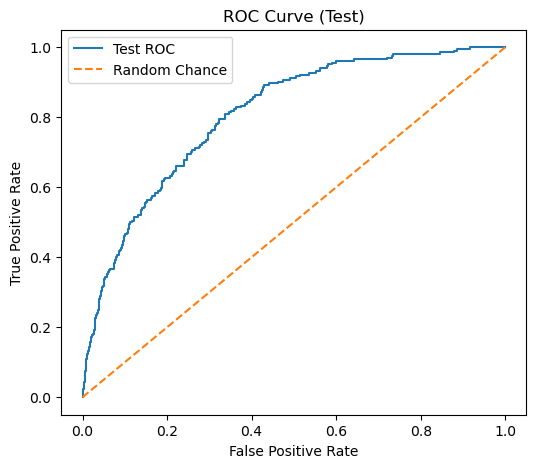

In [14]:
# Initialize the feature selector with your training DataFrame, feature columns, and any forced features.
fs = FeatureSelector(train_df, all_feature_columns)

# Run feature selection using the desired method(s)
# available --> ['mutual_info', 'random_forest', 'xgboost']
fs.run_feature_selection(methods=['mutual_info'], n_features=50)

# Retrieve the selected features for a given method
feature_columns = fs.get_selected_features('mutual_info')

# Plot the importance scores for the selected method
fs.plot_feature_importance('mutual_info', top_n=50)

# Initialize and train model with all features
X_train, X_train_scaled, model, scaler = train_model(train_df, feature_columns, "xgboost")
X_test, X_test_scaled, y_test, y_pred_test, results = predict_and_analyze_model(model, scaler, train_df, test_df, feature_columns)

c:\Users\bdion\Downloads\DSC180B\DSC180B\.conda\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         6,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,897 (66.00 KB)

 Trainable params: 16,897 (66.00 KB)

 Non-trainable params: 0 (0.00 B)


Class Distribution:
DQ_TARGET
0.0    0.912448
1.0    0.087552
Name: proportion, dtype: float64

Class Weights:
{0: 0.5479764532744665, 1: 5.710889570552148}
Epoch 1/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - AUC: 0.5917 - accuracy: 0.4703 - loss: 0.7128 - val_AUC: 0.7333 - val_accuracy: 0.6779 - val_loss: 0.5936
Epoch 2/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - AUC: 0.6968 - accuracy: 0.6336 - loss: 0.6638 - val_AUC: 0.7478 - val_accuracy: 0.6826 - val_loss: 0.5387
Epoch 3/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - AUC: 0.7517 - accuracy: 0.6551 - loss: 0.6091 - val_AUC: 0.7484 - val_accuracy: 0.6779 - val_loss: 0.5630
Epoch 4/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - AUC: 0.7595 - accuracy: 0.6566 - loss: 0.6000 - val_AUC: 0.7524 - val_accuracy: 0.6772 - val_loss: 0.5598
Epoch 5/100
187/187 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - AUC: 0.7658 - accuracy: 0.6556 - loss: 0.5940 - val_AUC: 0.7543 - val_accuracy: 0.6658 - val_loss: 0.5559
Epoch 6/100
187/187 ━━━━━━━━━━━━━

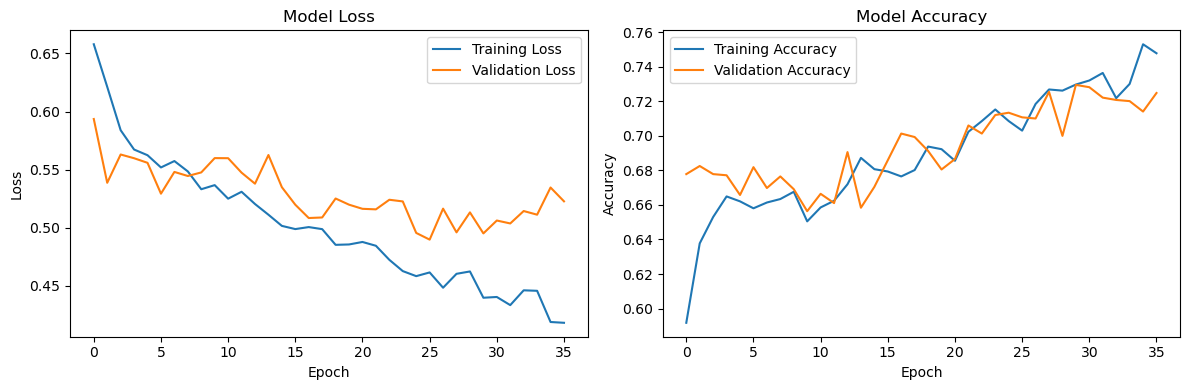


Input Data Statistics:
Mean: 7.203703041478121e-19
Std: 1.0
Min: -44.75599711268281
Max: 85.81613312441002

Prediction Distribution:
0    0.705598
1    0.294402
Name: proportion, dtype: float64

Prediction Distribution:
0    0.694776
1    0.305224
Name: proportion, dtype: float64


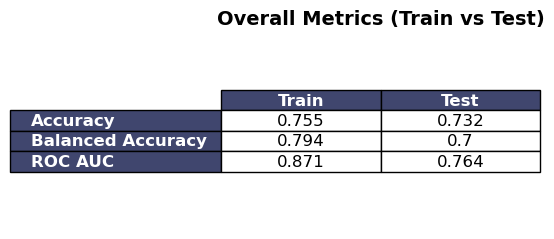


=== Classification Report (Train vs Test) ===
                 Train                                       Test                                 
             precision    recall  f1-score      support precision    recall  f1-score      support
0.0           0.980093  0.746284  0.847356  6795.000000  0.960616  0.738482  0.835029  2279.000000
1.0           0.241531  0.842025  0.375385   652.000000  0.184679  0.661765  0.288770   204.000000
accuracy      0.754666  0.754666  0.754666     0.754666  0.732179  0.732179  0.732179     0.732179
macro avg     0.610812  0.794154  0.611370  7447.000000  0.572647  0.700123  0.561899  2483.000000
weighted avg  0.915430  0.754666  0.806034  7447.000000  0.896866  0.732179  0.790149  2483.000000


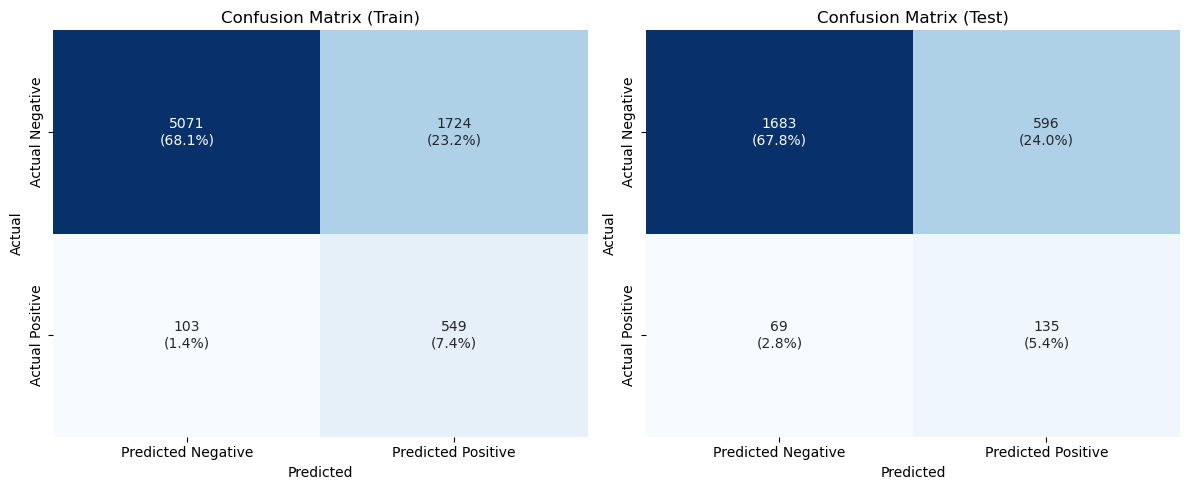

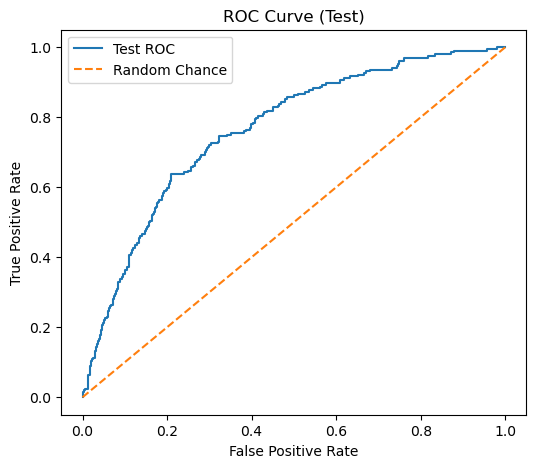

In [15]:
# Retrieve the selected features for a given method
feature_columns = fs.get_selected_features('mutual_info')

# Initialize and train model with selected features
X_train, X_train_scaled, nn_model, scaler = train_model(train_df, feature_columns, "neural_network")

# Check the scale of the input data
print("\nInput Data Statistics:")
print("Mean:", X_train_scaled.mean())
print("Std:", X_train_scaled.std())
print("Min:", X_train_scaled.min())
print("Max:", X_train_scaled.max())

# Analyze model performance
results = predict_and_analyze_model(
    nn_model, 
    scaler, 
    train_df, 
    test_df, 
    feature_columns,
    show_metrics=True,
    show_classification_report=True,
    show_confusion_matrix=True,
    show_roc_curve=True
)

## 5. SHAP

- Most impactful features for the model overall (according to SHAP):

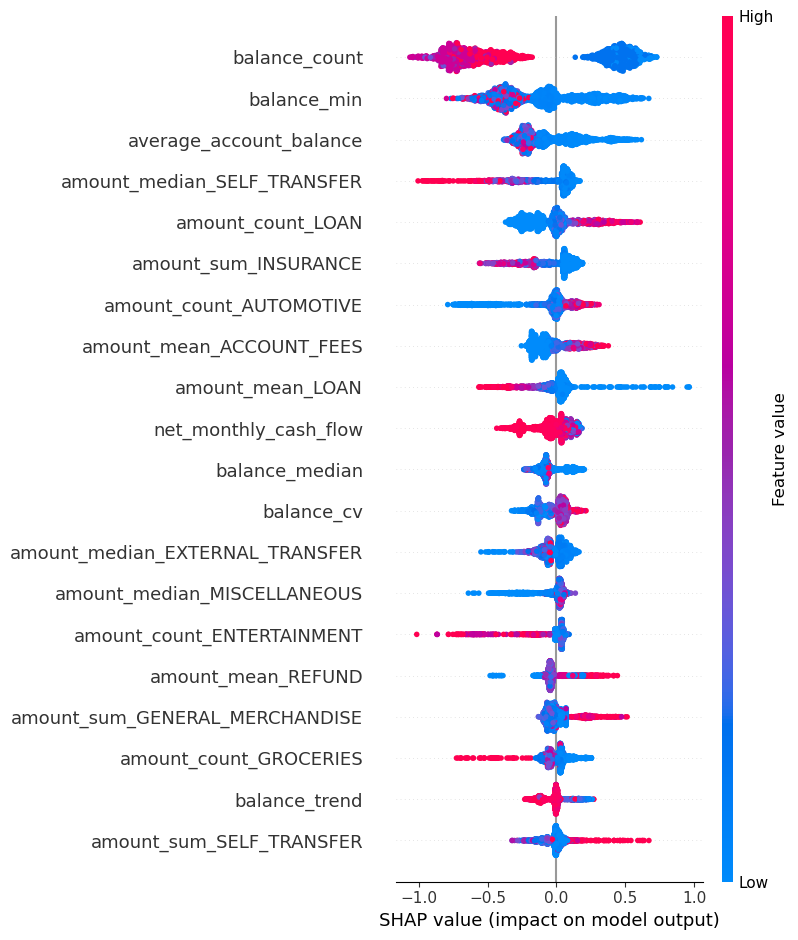

In [16]:
scaled_feats, explainer, shap_values = shap_plots(model, X_test, X_test_scaled)

- Waterfall plot for an individual person:
    - Person here was predicted as not defaulting

In [17]:
y_pred_test[0]

0

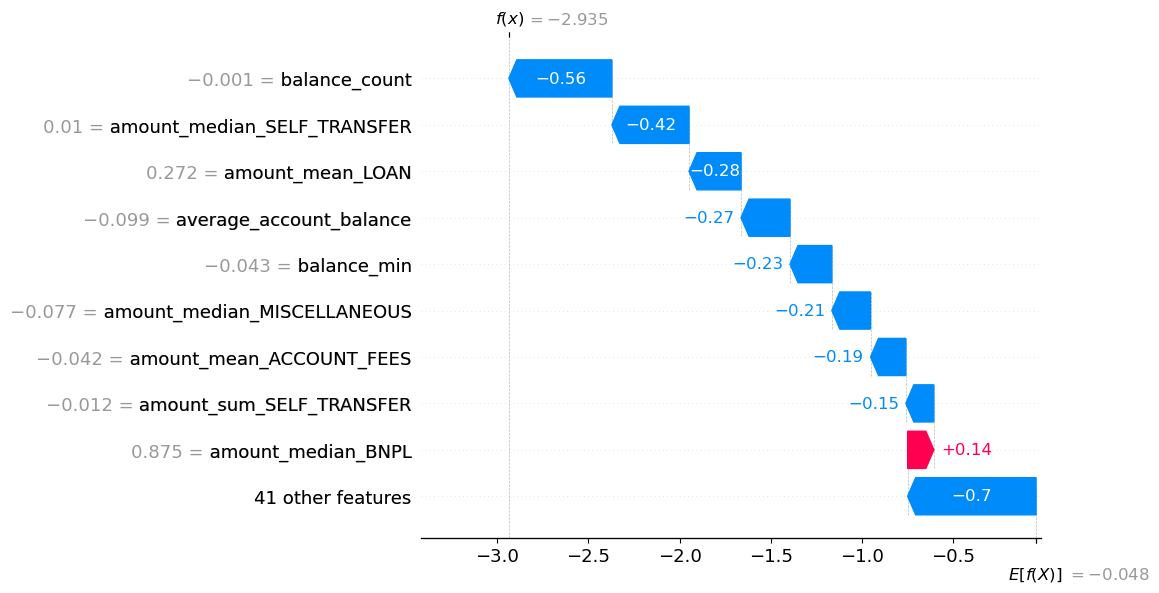

In [18]:
shap.plots.waterfall(shap_values[0])

- Reason codes for default:

In [19]:
scaled_feats['y_true'] = y_test.values
scaled_feats['y_pred'] = y_pred_test

shap_values = explainer(scaled_feats.drop(columns=['y_true', 'y_pred']))

shap_df = pd.DataFrame(shap_values.values, columns=scaled_feats.drop(columns=['y_true', 'y_pred']).columns)

mask = scaled_feats['y_pred'] == 1
shap_df_pred_default = shap_df[mask].reset_index(drop=True)

def get_top_feature_names(shap_row, feature_names, top_n=3):
    top_indices = np.argsort(shap_row)[::-1][:top_n]  
    return [feature_names[i] for i in top_indices]  

top_features_pred_default = shap_df_pred_default.apply(
    lambda row: get_top_feature_names(row, shap_df.columns), axis=1
)

top_features_df = pd.DataFrame(top_features_pred_default.tolist(), columns=['Feature_1', 'Feature_2', 'Feature_3'])
top_features_df

,Feature_1,Feature_2,Feature_3
0,balance_count,amount_mean_ACCOUNT_FEES,amount_sum_INSURANCE
1,balance_count,average_account_balance,amount_sum_INSURANCE
2,balance_count,amount_sum_INSURANCE,amount_median_INVESTMENT_INCOME
3,balance_count,amount_count_GROCERIES,balance_median
4,balance_count,balance_min,amount_mean_ACCOUNT_FEES
...,...,...,...
627,amount_count_LOAN,balance_count,balance_min
628,balance_count,balance_min,average_account_balance
629,amount_sum_GENERAL_MERCHANDISE,amount_count_AUTOMOTIVE,amount_mean_ACCOUNT_FEES
630,balance_count,balance_min,average_account_balance


In [20]:
reasons = top_features_pred_default.explode().value_counts().reset_index()
reasons.rename(columns={'index':'Reason'}, inplace=True)

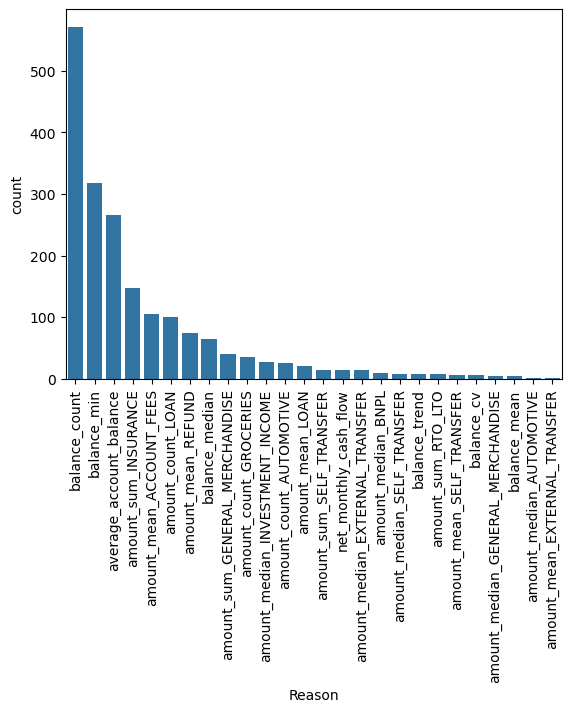

In [21]:
sns.barplot(reasons, x='Reason', y='count');
plt.xticks(rotation=90);

## 6. Heldout Set Predictions

In [22]:
# get the original dataframe
consumer_df, account_df, transaction_df = get_data()

Data successfully loaded and processed.


In [23]:
# Identify the heldout set
heldout_df = consumer_df[consumer_df['DQ_TARGET'].isna()].copy()
print(f"Heldout set size: {len(heldout_df)}")

# Apply thin file identification to heldout set
enriched_heldout = identify_thin_files(
    transaction_df[transaction_df['prism_consumer_id'].isin(heldout_df['prism_consumer_id'])],
    account_df[account_df['prism_consumer_id'].isin(heldout_df['prism_consumer_id'])],
    heldout_df,
    min_transactions=3,
    min_transaction_months=1,
    min_balance_records=1
)

# Split into thick and thin files
thick_file_ids = enriched_heldout[~enriched_heldout['is_thin_file']]['prism_consumer_id']
thin_file_ids = enriched_heldout[enriched_heldout['is_thin_file']]['prism_consumer_id']

print(f"Thick files: {len(thick_file_ids)}")
print(f"Thin files: {len(thin_file_ids)}")

Heldout set size: 3000


c:\Users\bdion\Downloads\DSC180B\q2_repo\credit_scoring\src\scripts\utilities.py:1108: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  transaction_df['transaction_month'] = transaction_df['posted_date'].dt.to_period('M')


Thick files: 2462
Thin files: 538


In [24]:
# Process thick files with XGBoost
thick_heldout_consumer = heldout_df[heldout_df['prism_consumer_id'].isin(thick_file_ids)]
thick_heldout_account = account_df[account_df['prism_consumer_id'].isin(thick_file_ids)]
thick_heldout_transaction = transaction_df[transaction_df['prism_consumer_id'].isin(thick_file_ids)]

# Calculate features for thick files
feature_dataframes = execute_selected_features(selected_features, thick_heldout_account, thick_heldout_transaction)
thick_file_features = merge_features(feature_dataframes)

# Merge with consumer data
thick_file_ml_features = thick_heldout_consumer.merge(thick_file_features, how="left", on="prism_consumer_id")
thick_file_ml_features = thick_file_ml_features.apply(lambda col: col.fillna(0) if col.name != "DQ_TARGET" else col)

# Generate predictions for thick files using XGBoost
X_thick = thick_file_ml_features[feature_columns]
X_thick_scaled = scaler.transform(X_thick)
thick_file_probs = model.predict_proba(X_thick_scaled)[:, 1]

# Process thin files with simple logistic regression
thin_heldout_consumer = heldout_df[heldout_df['prism_consumer_id'].isin(thin_file_ids)]

# Train a simple logistic regression on basic features
basic_features = ['credit_score']

# Train logistic regression on the original training data
basic_X_train = train_df[basic_features]
basic_y_train = train_df['DQ_TARGET']

basic_model = LogisticRegression(class_weight='balanced')
basic_model.fit(basic_X_train, basic_y_train)

# Generate predictions for thin files
basic_X_heldout = thin_heldout_consumer[basic_features]
thin_file_probs = basic_model.predict_proba(basic_X_heldout)[:, 1]

# Combine predictions and create final output
thick_predictions = pd.DataFrame({
    'prism_consumer_id': thick_file_ml_features['prism_consumer_id'],
    'probability': thick_file_probs,
    'file_type': 'thick'
})


thin_predictions = pd.DataFrame({
    'prism_consumer_id': thin_heldout_consumer['prism_consumer_id'],
    'probability': thin_file_probs,
    'file_type': 'thin'
})

# Combine all predictions
all_predictions = pd.concat([thick_predictions, thin_predictions])


Feature Execution Plan:
- Total feature creation functions: 8
- Unchanged feature creation functions: 8 (using cached results)

No feature creation functions need to be executed.
- Using cached result for average_transaction_amount
- Using cached result for net_monthly_cash_flow
- Using cached result for average_account_balance
- Using cached result for time_based_average_transaction_amounts
- Using cached result for descriptive_stats_by_category
- Using cached result for outflow_stats
- Using cached result for outflow_over_time_fix
- Using cached result for balance_over_time

Total Created Features:  266



Prediction Summary:
Mean probability: 0.338
Mean score: 288.6

Predictions by file type:
            count      mean       std       min       25%       50%       75%  \
file_type                                                                       
thick      2462.0  0.325113  0.248826  0.003715  0.109765  0.269126  0.509977   
thin        538.0  0.397832  0.168153  0.057891  0.282045  0.392550  0.491789   

                max  
file_type            
thick      0.907024  
thin       0.895952  


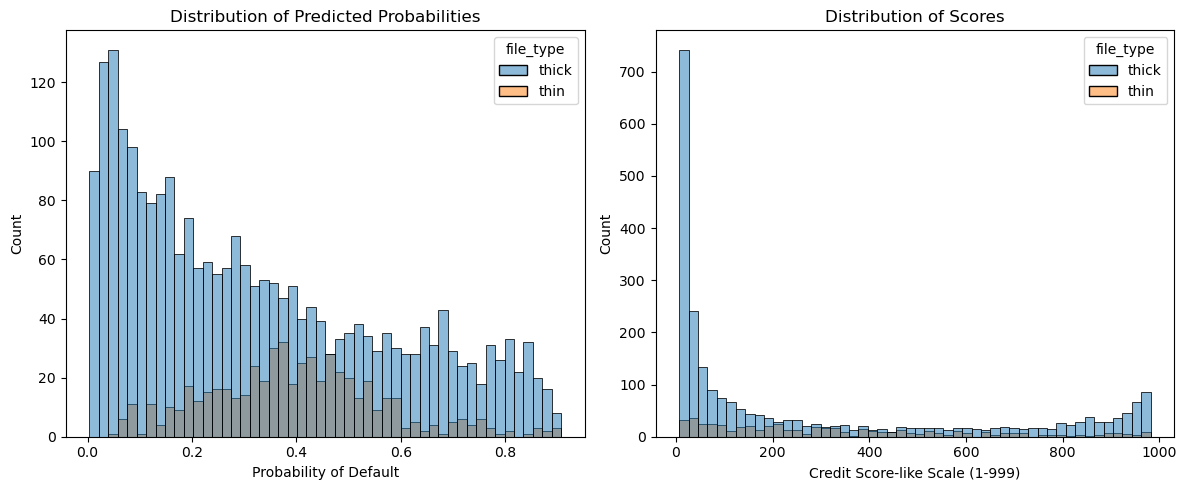

In [25]:
#Convert probabilities to credit score-like scale (1-999)
def prob_to_score(prob):
    """Convert probability to a credit score-like scale"""
    # Using a logistic transformation to spread out the scores
    score = 1 + int(998 / (1 + np.exp(-10 * (prob - 0.5))))
    return min(999, max(1, score))

all_predictions['score'] = all_predictions['probability'].apply(prob_to_score)

# Ensure we have predictions for all consumers
assert len(all_predictions) == len(heldout_df), "Missing predictions for some consumers"

# Sort by consumer ID for consistency
all_predictions = all_predictions.sort_values('prism_consumer_id')

# Add some analysis of the predictions
print("\nPrediction Summary:")
print(f"Mean probability: {all_predictions['probability'].mean():.3f}")
print(f"Mean score: {all_predictions['score'].mean():.1f}")
print("\nPredictions by file type:")
print(all_predictions.groupby('file_type')['probability'].describe())

# Create visualizations
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(data=all_predictions, x='probability', hue='file_type', bins=50)
plt.title('Distribution of Predicted Probabilities')
plt.xlabel('Probability of Default')

plt.subplot(1, 2, 2)
sns.histplot(data=all_predictions, x='score', hue='file_type', bins=50)
plt.title('Distribution of Scores')
plt.xlabel('Credit Score-like Scale (1-999)')

plt.tight_layout()
plt.show()

In [26]:
# Save predictions
output_path = '../predictions.csv'
all_predictions[['prism_consumer_id', 'score']].to_csv(output_path, index=False)
print(f"\nPredictions saved to: {output_path}")


Predictions saved to: ../predictions.csv


## 7. Reason Codes for Holdout Set:

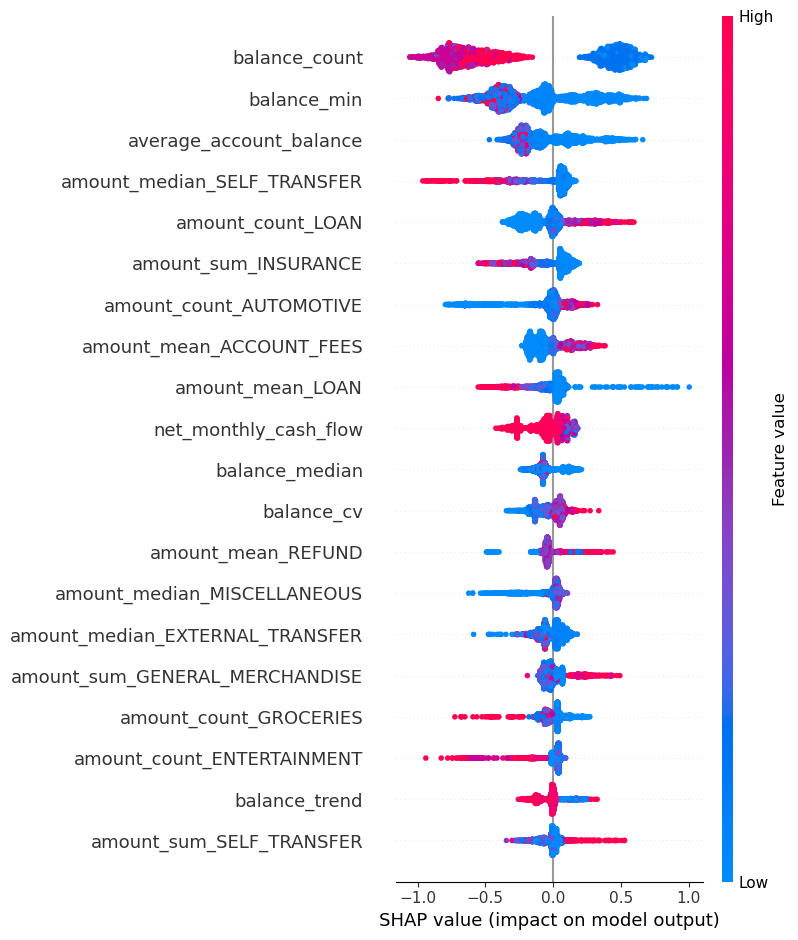

In [27]:
scaled_feats, explainer, shap_values = shap_plots(model, X_thick, X_thick_scaled)

In [28]:
scaled_feats['y_pred'] = thick_file_probs

shap_values = explainer(scaled_feats.drop(columns=['y_pred']))

shap_df = pd.DataFrame(shap_values.values, columns=scaled_feats.drop(columns=['y_pred']).columns)

def get_top_feature_names(shap_row, feature_names, top_n=3):
    top_indices = np.argsort(shap_row)[::-1][:top_n]  
    return [feature_names[i] for i in top_indices]  

top_features_pred_default = shap_df.apply(
    lambda row: get_top_feature_names(row, shap_df.columns), axis=1
)

top_features_df = pd.DataFrame(top_features_pred_default.tolist(), columns=['Feature_1', 'Feature_2', 'Feature_3'])
top_features_df

,Feature_1,Feature_2,Feature_3
0,amount_count_LOAN,amount_sum_INSURANCE,amount_mean_INVESTMENT
1,amount_median_SELF_TRANSFER,amount_median_EXTERNAL_TRANSFER,balance_cv
2,amount_sum_GENERAL_MERCHANDISE,balance_cv,net_monthly_cash_flow
3,amount_count_AUTOMOTIVE,amount_median_BNPL,amount_median_SELF_TRANSFER
4,amount_sum_SELF_TRANSFER,amount_median_MISCELLANEOUS,amount_count_ENTERTAINMENT
...,...,...,...
2457,amount_median_SELF_TRANSFER,amount_median_GENERAL_MERCHANDISE,balance_cv
2458,amount_count_LOAN,amount_sum_GENERAL_MERCHANDISE,amount_count_AUTOMOTIVE
2459,amount_count_LOAN,amount_mean_ACCOUNT_FEES,amount_sum_GENERAL_MERCHANDISE
2460,amount_mean_ACCOUNT_FEES,balance_trend,amount_count_ACCOUNT_FEES


In [29]:
reasons = top_features_pred_default.explode().value_counts().reset_index()
reasons.rename(columns={'index':'Reason'}, inplace=True)

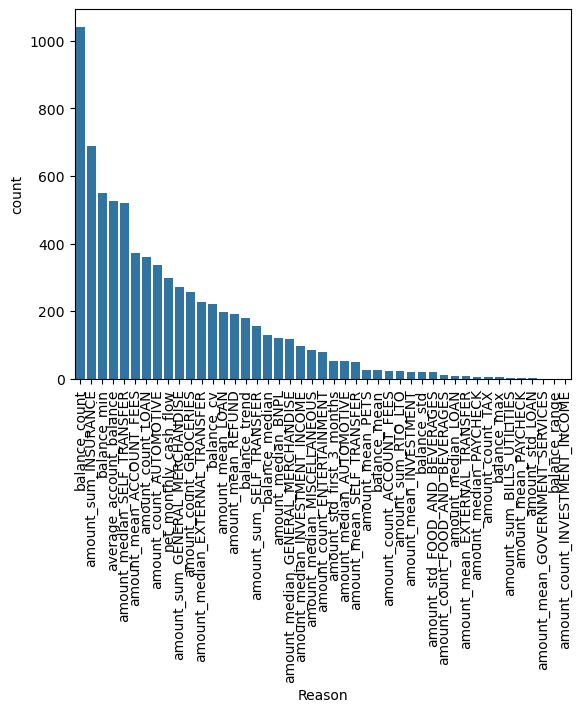

In [30]:
sns.barplot(reasons, x='Reason', y='count');
plt.xticks(rotation=90);

## 8 Cash Score vs Credit Score

In [ ]:
generate_cash_scores(model, scaler, feature_columns, train_df)

In [ ]:
cash_vs_credit_score(model, scaler, feature_columns, test_df, consumer_df)